In [1]:
import json
import numpy as np
from openai import OpenAI, AsyncOpenAI
import openai
from collections import defaultdict
import pytrec_eval
from string import Template
import pytrec_eval
import random
print(openai.__version__)
apikey = ''
client = AsyncOpenAI(api_key=apikey)
random.seed(0)

1.90.0


In [2]:
import sys
sys.path.append('./..')
from order_by.sorting import *
from order_by.utils import *
from prompts.all_prompts import *
from order_by.pointwise import *

In [3]:
from dataclasses import dataclass
from tqdm import tqdm

@dataclass
class SearchResult:
    docid: str
    score: float
    text: str

In [4]:
import ir_datasets

# # Discover all available msmarco-passage-v2 variants
# for d in ir_datasets.registry:
#     if "msmarco-passage" in d:
#         print(d)

ds = ir_datasets.load("msmarco-passage/trec-dl-2020")
# Build qrels dict
qrels_by_qid = defaultdict(dict)
for q in ds.qrels_iter():                      # has query_id, doc_id, relevance
    qrels_by_qid[str(q.query_id)][str(q.doc_id)] = int(q.relevance)
qrels_by_qid = dict(qrels_by_qid)


In [5]:
print("Docs:", ds.docs_count())      # Number of docs
print("Queries:", ds.queries_count())# Number of queries
print("Qrels:", ds.qrels_count())    # Number of qrels

passage_length = 1024
query_map = {}
for query in ds.queries_iter():
    # query.query_id → string ID
    # query.text → raw query text
    gpt_encoding = tiktoken.encoding_for_model("gpt-3.5-turbo")
    query_map[query.query_id] = gpt_encoding.decode( gpt_encoding.encode(query.text)[:passage_length] )
print(len(query_map))


Docs: 8841823
Queries: 200
Qrels: 11386
200


In [6]:
doc_lookup = {}
for doc in ds.docs_iter():
    doc_lookup[doc.doc_id] = {
        "contents": doc.text
    }
    # Add title if it exists in dataset (some have no title)
    if hasattr(doc, "title") and doc.title:
        doc_lookup[doc.doc_id]["title"] = doc.title

In [7]:
bm25_dl19_txt = '../data/run.msmarco-v1-passage.bm25-default.dl20.txt'
def load_run_file(path, query_map, doc_lookup, hits=100):
    first_stage_rankings = []
    query_id_to_list = defaultdict(list)
    with open(path, 'r') as f:
        current_qid = None
        current_ranking = []
        for line in tqdm(f):
            qid, _, docid, _, score, _ = line.strip().split()
            if qid not in query_map:
                print(qid)
                print('???')
                continue
                
            doc_data = doc_lookup[docid]
            text = doc_data["contents"]
            if "title" in doc_data:
                text = f'{doc_data["title"]} {text}'

            text = gpt_encoding.decode(gpt_encoding.encode(text)[:passage_length])
            
            
            query_id_to_list[qid].append(SearchResult(docid=docid, score=float(score), text=text))
            
    for qid, current_ranking in query_id_to_list.items():
        first_stage_rankings.append((qid, query_map[qid], current_ranking[:hits]))
    return first_stage_rankings

In [8]:
first_stage_rankings = load_run_file(bm25_dl19_txt, query_map, doc_lookup, 100)

first_stage_rankings = [
    (qid, q, r) for qid, q, r in first_stage_rankings if str(qid) in qrels_by_qid
]
assert len(first_stage_rankings) == 54

200000it [00:36, 5470.92it/s]


In [9]:
print(len(first_stage_rankings))
# should be 54!
assert len(first_stage_rankings)==54

54


# Filter with BM25

In [10]:
class SafeDict(dict):
    def __missing__(self, k):  # leave untouched
        return '{' + k + '}'

In [11]:
evaluator = pytrec_eval.RelevanceEvaluator(qrels_by_qid, {'ndcg_cut.10'})

bm25_run = {}
for qid, query, ranking in first_stage_rankings:
    bm25_run[str(qid)] = {str(r.docid): float(r.score) for r in ranking}

metrics = evaluator.evaluate(bm25_run)


mean_ndcg10 = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
print("BM25 Mean nDCG@10:", mean_ndcg10)

BM25 Mean nDCG@10: 0.47963667242526753


In [12]:
print(len(qrels_by_qid))
print(len(bm25_run))

54
54


In [13]:
def tokens2price(model, in_tokens, out_tokens):
    """
    Calculate the API cost given the model and number of input/output tokens.

    Pricing (as of Sep 2025):
    - gpt-4o:       $2.50 per 1M input tokens, $10.00 per 1M output tokens
    - gpt-4o-mini:  $0.150 per 1M input tokens, $0.600 per 1M output tokens
    """
    if model == 'gpt-4o':
        input_rate = 2.50 / 1_000_000
        output_rate = 10.00 / 1_000_000
    elif model == 'gpt-4o-mini':
        input_rate = 0.150 / 1_000_000
        output_rate = 0.600 / 1_000_000
    else:
        raise ValueError(f"Unknown model: {model}")

    total_cost = in_tokens * input_rate + out_tokens * output_rate
    return round(total_cost, 6) 
        

# Optimizer

In [14]:
from order_by.optimizer import *
for modelname, budget in [("gpt-4o-mini", 10), ("gpt-4o-mini", 200), ("gpt-4o", 150), ("gpt-4o", 800)]:
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    total_budget = budget
    
    print(len(first_stage_rankings))
    
    num_question = 0
    
    for qid, query, ranking in tqdm(first_stage_rankings):
        curr_budget = 1.0 * budget / (len(first_stage_rankings)-num_question)
        
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) ) 

        optimizer = OrderByOptimizer(client, passage_list[:], 
                                    membership_inference_prompt.format_map(SafeDict(description="question and passage pair")),
                                    passage_pointwise_prompt_template.format_map(SafeDict(question=query)),
                                    passage_external_pointwise_prompt_template.format_map(SafeDict(question=query)),
                                    passage_pairwise_comparison_prompt_template.format_map(SafeDict(question=query)),
                                    passage_external_comparison_prompt_template.format_map(SafeDict(question=query)),
                                    curr_budget, modelname, isPassage=True)

        sorted_data, num_api_calls, in_tokens, out_tokens = await optimizer.physical_order_by_impl()
        if type(sorted_data[0]) == tuple:
            run[str(qid)] = {
                str(doc_id): float(1.0 * i / (len(sorted_data) - 1))
                for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            
        else:
            run[str(qid)] = {
                str(doc_id): float(1.0 * i / (len(sorted_data) - 1))
                for doc_id, i in zip( sorted_data, range(len(sorted_data)) )
            }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
        budget -= tokens2price(modelname, in_tokens, out_tokens)
        num_question += 1

    metrics = evaluator.evaluate(run)
    mean_ndcg = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"given budget {total_budget}")
    print(f"{modelname}, optimizer output nDCG@10:", mean_ndcg)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")


54


  0%|                                                    | 0/54 [00:00<?, ?it/s]

ext_bubble_4 estimated cost 0.20995
ext_merge_4 estimated cost 0.025820642068219362
from window m=2: 2.5 from window 2m: 2.0
from window m=2: 1.5 from window 2m: 3.0
from window m=2: 1.0 from window 2m: 0.0
Final memory size for external pointwise: m = 2 (agreement = 0.25)
point estimated cost 0.014799999999999999
ext_point estimated cost 0.010124999999999999
quick estimated cost 0.07744633124202266
ext_merge_4 estimated cost 0.03701206154446017
ext_bubble_4 estimated cost 0.23232818181818182
------------------
decided to use quick
------------------


  2%|▊                                           | 1/54 [00:00<00:45,  1.17it/s]

ext_bubble_4 estimated cost 0.238
ext_merge_4 estimated cost 0.030053534210550407
from window m=2: 0.0 from window 2m: 0.5
from window m=2: 0.5 from window 2m: 0.0
from window m=2: 0.5 from window 2m: 0.0
Final memory size for external pointwise: m = 2 (agreement = 0.25)
point estimated cost 0.01569
ext_point estimated cost 0.010254999999999998
quick estimated cost 0.0835953055367446
ext_merge_4 estimated cost 0.039373629850487236
ext_bubble_4 estimated cost 0.25414227272727274
------------------
decided to use ext_merge_4
------------------


...

ext_bubble_4 estimated cost 3.4539750000000002
ext_merge_4 estimated cost 0.4201850933287282
from window m=2: 1.5 from window 2m: 1.0
from window m=2: 1.0 from window 2m: 0.5
Final memory size for external pointwise: m = 2 (agreement = 0.50)
point estimated cost 0.29284999999999994
ext_point estimated cost 0.15014
quick estimated cost 1.4286526876356924
quick_3 estimated cost 3.179880566772497
ext_merge_4 estimated cost 0.5082468767971201
ext_bubble_4 estimated cost 3.559058181818182
------------------
decided to use quick
------------------


 98%|████████████████████████████████████████▏| 53/54 [3:09:06<00:44, 44.16s/it]

ext_bubble_4 estimated cost 3.9397500000000005
ext_merge_4 estimated cost 0.495248380652732
from window m=2: 1.0 from window 2m: 0.5
from window m=2: 2.5 from window 2m: 1.5
from window m=2: 1.5 from window 2m: 1.0
Final memory size for external pointwise: m = 2 (agreement = 0.25)
point estimated cost 0.30374
ext_point estimated cost 0.168175
quick estimated cost 1.4829020133508766
quick_3 estimated cost 3.326114704827787
ext_merge_4 estimated cost 0.5448596803905613
ext_bubble_4 estimated cost 4.141431818181818
------------------
decided to use quick
------------------


100%|████████████████████████████████████████| 54/54 [3:09:11<00:00, 210.21s/it]

given budget 800
gpt-4o, optimizer output nDCG@10: 0.7017403831536299
tokens: 35358289, price: 209.52637


In [ ]:
given budget 10
gpt-4o-mini, optimizer output nDCG@10: 0.6647875148350357
tokens: 18780325, price: 6.674178

given budget 200
gpt-4o-mini, optimizer output nDCG@10: 0.6623403365614713
tokens: 23386343, price: 8.141381
        
given budget 150
gpt-4o, optimizer output nDCG@10: 0.7043950194044065
tokens: 24887814, price: 144.583125

given budget 800
gpt-4o, optimizer output nDCG@10: 0.7017403831536299
tokens: 35358289, price: 209.52637

# Pointwise experiments

In [19]:
results = {}

for modelname in ["gpt-4o-mini", "gpt-4o"]:
    results[modelname] = {}
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
        
    for qid, query, ranking in tqdm(first_stage_rankings):
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) ) 
            
        # print(ranking) # docid, score, text
        pointwise_prompt_template = passage_pointwise_prompt_template.format_map(SafeDict(question=query))

        sorted_data, scores, num_api_calls, in_tokens, out_tokens, confidences =\
            await pointwise_sort(passage_list, client, pointwise_prompt_template,
                                 modelname, float, PointwiseRelevanceKey)
        run[str(qid)] = {str(doc_id): float(score) for doc_id, score in zip(sorted_data, scores)}
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
        
    metrics = evaluator.evaluate(run)
    mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, pointwise Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")

    
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    
    for qid, query, ranking in tqdm(first_stage_rankings):
        print(qid, query)
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) )
        external_pointwise_prompt_template = passage_external_pointwise_prompt_template.format_map(SafeDict(question=query))
        sorted_data, scores, num_api_calls, in_tokens, out_tokens, confidences, _ =\
            await external_pointwise_sort(passage_list, external_values, client, external_pointwise_prompt_template,\
                                          modelname, float, 0.1, isPassage=True)
        run[str(qid)] = {str(doc_id): float(score) for doc_id, score in zip(sorted_data, scores)}
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
    metrics = evaluator.evaluate(run)
    mean_external_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, extrernal pointwise Mean nDCG@10:", mean_external_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")


100%|███████████████████████████████████████████| 54/54 [00:03<00:00, 17.28it/s]


gpt-4o-mini, pointwise Mean nDCG@10: 0.6448519968848119
tokens: 2029606, price: 0.807508


 13%|█████▋                                      | 7/54 [00:00<00:00, 65.37it/s]

23849 are naturalization records public information
from window m=4: 1.0 from window 2m: 0.0
from window m=4: 1.0 from window 2m: 0.0
from window m=4: 1.5 from window 2m: 1.0
from window m=4: 1.0 from window 2m: 0.0
Final memory size for external pointwise: m = 4 (agreement = 0.50)
42255 average salary for dental hygienist in nebraska
from window m=2: 3.0 from window 2m: 1.5
from window m=4: 1.5 from window 2m: 1.0
Final memory size for external pointwise: m = 8
47210 average wedding dress alteration cost
from window m=2: 2.5 from window 2m: 2.0
from window m=4: 2.5 from window 2m: 2.0
Final memory size for external pointwise: m = 8
67316 can fever cause miscarriage early pregnancy
from window m=2: 1.0 from window 2m: 0.0
from window m=2: 1.5 from window 2m: 0.0
Final memory size for external pointwise: m = 2 (agreement = 0.50)
118440 define bmt medical
from window m=2: 0.5 from window 2m: 0.0
from window m=2: 2.0 from window 2m: 0.0
Final memory size for external pointwise: m = 2 (agr

 41%|█████████████████▌                         | 22/54 [00:00<00:00, 62.57it/s]

...

1116380 what is a nonconformity? earth science
from window m=8: 0.5 from window 2m: 0.0
from window m=8: 1.0 from window 2m: 0.0
from window m=8: 1.5 from window 2m: 0.0
Final memory size for external pointwise: m = 32
1121353 what can you do about discrimination in the workplace in oklahoma city
from window m=2: 2.0 from window 2m: 2.5
from window m=2: 2.5 from window 2m: 2.0
from window m=2: 2.0 from window 2m: 1.5
Final memory size for external pointwise: m = 2 (agreement = 0.25)
1122767 what amino produces carnitine
from window m=2: 1.5 from window 2m: 1.0
from window m=2: 1.5 from window 2m: 1.0
from window m=2: 2.5 from window 2m: 3.0
Final memory size for external pointwise: m = 2 (agreement = 0.25)
1127540 meaning of shebang
from window m=2: 3.0 from window 2m: 2.5
from window m=2: 3.0 from window 2m: 2.5
from window m=2: 3.0 from window 2m: 2.5
Final memory size for external pointwise: m = 2 (agreement = 0.25)
1131069 how many sons robert kraft has
from window m=4: 0.5 from wi

 98%|██████████████████████████████████████████▏| 53/54 [03:18<00:01,  1.82s/it]

1133579 how does granulation tissue start
from window m=2: 0.7 from window 2m: 0.5
from window m=2: 1.0 from window 2m: 2.5
from window m=2: 2.5 from window 2m: 3.0
Final memory size for external pointwise: m = 2 (agreement = 0.25)
1136043 difference between a hotel and motel
from window m=2: 2.5 from window 2m: 1.5
from window m=2: 0.5 from window 2m: 1.0
from window m=2: 2.5 from window 2m: 1.5
Final memory size for external pointwise: m = 2 (agreement = 0.25)
1136047 difference between a company's strategy and business model is
from window m=2: 1.0 from window 2m: 1.5
from window m=2: 1.0 from window 2m: 0.5
from window m=2: 2.5 from window 2m: 1.0
Final memory size for external pointwise: m = 2 (agreement = 0.25)
1136962 why did the ancient egyptians call their land kemet, or black land?
from window m=2: 2.0 from window 2m: 1.5
from window m=4: 2.5 from window 2m: 3.0
from window m=8: 2.5 from window 2m: 3.0
from window m=8: 1.5 from window 2m: 2.0
from window m=8: 1.5 from window 

100%|███████████████████████████████████████████| 54/54 [03:31<00:00,  3.91s/it]

gpt-4o, extrernal pointwise Mean nDCG@10: 0.6030793060914266
tokens: 1483884, price: 7.506405


In [ ]:
gpt-4o-mini, pointwise Mean nDCG@10: 0.6448519968848119
tokens: 2029606, price: 0.807508

gpt-4o-mini, extrernal pointwise Mean nDCG@10: 0.5815175397221886
tokens: 1487222, price: 0.471419
    
gpt-4o, pointwise Mean nDCG@10: 0.6554964445713343
tokens: 2253664, price: 15.699048

gpt-4o, extrernal pointwise Mean nDCG@10: 0.5899715955281896
tokens: 1047262, price: 5.743203

# Pairwise experiments

In [13]:
print('start')

start


In [14]:
results = {}

for modelname in ["gpt-4o-mini", "gpt-4o"]:        
    results[modelname] = {}
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    for qid, query, ranking in tqdm(first_stage_rankings):
        print(qid)
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) ) 
            
        pairwise_comparison_prompt_template = passage_pairwise_comparison_prompt_template.format_map(SafeDict(question=query))
        vote = 1
        sorted_data, num_api_calls, in_tokens, out_tokens =\
            await quick_sort(passage_list, client, pairwise_comparison_prompt_template, modelname, True, vote)
        run[str(qid)] = {
            str(doc_id): float(1.0 * i / (len(sorted_data) - 1))
            for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
    metrics = evaluator.evaluate(run)
    mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")

    
    run = {}
    total_input_tokens = 0
    total_output_tokens = 0
    for qid, query, ranking in tqdm(first_stage_rankings):
        print(qid)
        passage_list = []
        for r in ranking:
            passage_list.append( (r.docid, r.text) ) 
            
        pairwise_comparison_prompt_template = passage_pairwise_comparison_prompt_template.format_map(SafeDict(question=query))
        vote = 3
        sorted_data, num_api_calls, in_tokens, out_tokens =\
            await quick_sort(passage_list, client, pairwise_comparison_prompt_template, modelname, True, vote)
        run[str(qid)] = {
            str(doc_id): float(1.0 * i / (len(sorted_data) - 1))
            for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
        }
        total_input_tokens += in_tokens
        total_output_tokens += out_tokens
        
    metrics = evaluator.evaluate(run)
    mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
    print(f"{modelname}, quick_sort with vote={vote} Mean nDCG@10:", mean_pointwise)
    print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")

    

  0%|                                                    | 0/54 [00:00<?, ?it/s]

23849


  2%|▊                                           | 1/54 [00:00<00:24,  2.18it/s]

42255


  4%|█▋                                          | 2/54 [00:01<00:27,  1.91it/s]

...

1136047


 98%|█████████████████████████████████████▎| 53/54 [20:30:10<25:56, 1556.46s/it]

1136962
[ERROR] Attempt 1: Request timed out.


100%|██████████████████████████████████████| 54/54 [21:01:04<00:00, 1401.19s/it]

gpt-4o, quick_sort with vote=3 Mean nDCG@10: 0.7196054776362263
tokens: 52014005, price: 315.026682


In [ ]:
gpt-4o-mini, quick_sort Mean nDCG@10: 0.673088012156282
tokens: 19380112, price: 7.093272

gpt-4o-mini, quick_sort with vote=3 Mean nDCG@10: 0.6628282551098393
tokens: 43388495, price: 14.76262
    
gpt-4o, quick_sort Mean nDCG@10: 0.7143390300704658
tokens: 24635286, price: 158.362327
    
gpt-4o, quick_sort with vote=3 Mean nDCG@10: 0.7196054776362263
tokens: 52014005, price: 315.026682

In [13]:
for modelname in ["gpt-4o-mini", "gpt-4o"]:
    memory = [4, 8]
    if "mini" in modelname:
        memory = [4]
    
    for m in memory:
        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        for qid, query, ranking in tqdm(first_stage_rankings):
            print(qid)
            passage_list = []
            for r in ranking:
                passage_list.append( (r.docid, r.text) ) 

            external_comparison_prompt_template = passage_external_comparison_prompt_template.format_map(SafeDict(question=query))
            sorted_data, num_api_calls, in_tokens, out_tokens =\
                await external_bubble_sort(passage_list, external_comparisons, m, client, external_comparison_prompt_template, modelname, True, False)

            run[str(qid)] = {
                str(doc_id): float(1.0 * i / (len(sorted_data) - 1))
                for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
        
        metrics = evaluator.evaluate(run)
        mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
        print(f"{modelname}, external_bubble_sort Mean nDCG@10:", mean_pointwise)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")




        run = {}
        total_input_tokens = 0
        total_output_tokens = 0
        for qid, query, ranking in tqdm(first_stage_rankings):
            print(qid)
            passage_list = []
            for r in ranking:
                passage_list.append( (r.docid, r.text) ) 

            external_comparison_prompt_template = passage_external_comparison_prompt_template.format_map(SafeDict(question=query))
            sorted_data, num_api_calls, in_tokens, out_tokens =\
                await external_merge_sort(passage_list, external_comparisons, m, client, external_comparison_prompt_template, modelname, True, False)

            run[str(qid)] = {
                str(doc_id): float(1.0 * i / (len(sorted_data) - 1))
                for (doc_id, text), i in zip( sorted_data, range(len(sorted_data)) )
            }
            total_input_tokens += in_tokens
            total_output_tokens += out_tokens
        metrics = evaluator.evaluate(run)
        mean_pointwise = sum(m['ndcg_cut_10'] for m in metrics.values()) / len(metrics)
        print(f"{modelname}, external_merge_sort Mean nDCG@10:", mean_pointwise)
        print(f"tokens: {total_input_tokens + total_output_tokens}, price: {tokens2price(modelname, total_input_tokens, total_output_tokens)}")


  0%|                                                    | 0/54 [00:00<?, ?it/s]

23849


  2%|▊                                           | 1/54 [00:00<00:52,  1.01it/s]

42255


  4%|█▋                                          | 2/54 [00:02<00:53,  1.02s/it]

...

1131069
1132532
1133579


 96%|█████████████████████████████████████████▍ | 52/54 [00:04<00:00, 12.59it/s]

1136043
1136047
1136962


100%|███████████████████████████████████████████| 54/54 [00:04<00:00, 12.35it/s]

gpt-4o, external_merge_sort Mean nDCG@10: 0.7083708459946608
tokens: 5002711, price: 25.657293


In [ ]:
gpt-4o-mini, external_bubble_sort Mean nDCG@10: 0.6641741784435999
tokens: 50691442, price: 17.103403
    
gpt-4o-mini, external_merge_sort Mean nDCG@10: 0.6706319549422796
tokens: 7943468, price: 2.690268
    
    
gpt-4o, external_bubble_sort Mean nDCG@10: 0.6888569788585854
tokens: 49147670, price: 269.540795
    
gpt-4o, external_merge_sort Mean nDCG@10: 0.705613646664037
tokens: 7590204, price: 41.939348
    

gpt-4o, external_bubble_sort Mean nDCG@10: 0.702072982397344
tokens: 21648492, price: 110.877533
    
gpt-4o, external_merge_sort Mean nDCG@10: 0.7083708459946608
tokens: 5002711, price: 25.657293

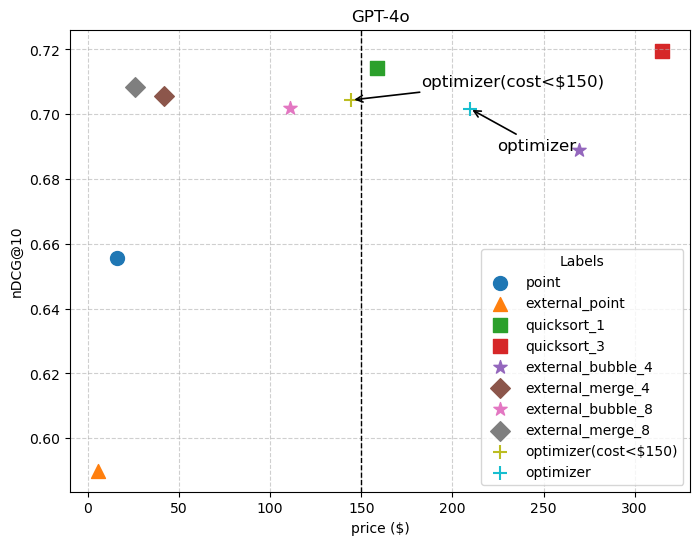

In [19]:
# gpt-4o, pointwise Mean nDCG@10: 0.6554964445713343
# tokens: 2253664, price: 15.699048

# gpt-4o, extrernal pointwise Mean nDCG@10: 0.5899715955281896
# tokens: 1047262, price: 5.743203
    
# gpt-4o, quick_sort Mean nDCG@10: 0.7143390300704658
# tokens: 24635286, price: 158.362327
    
# gpt-4o, quick_sort with vote=3 Mean nDCG@10: 0.7196054776362263
# tokens: 52014005, price: 315.026682

# gpt-4o, external_bubble_sort Mean nDCG@10: 0.6888569788585854
# tokens: 49147670, price: 269.540795
    
# gpt-4o, external_merge_sort Mean nDCG@10: 0.705613646664037
# tokens: 7590204, price: 41.939348
    

# gpt-4o, external_bubble_sort Mean nDCG@10: 0.702072982397344
# tokens: 21648492, price: 110.877533
    
# gpt-4o, external_merge_sort Mean nDCG@10: 0.7083708459946608
# tokens: 5002711, price: 25.657293
        

from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

kendalltau = [0.6554964445713343, 0.5899715955281896,
              0.7143390300704658,  0.7196054776362263,
              0.6888569788585854,  0.705613646664037,
              0.702072982397344, 0.7083708459946608
             ]
tokens = [2253664, 1047262,
          24635286, 52014005,
          49147670, 7590204,
          21648492, 5002711
         ]
prices = [15.699048, 5.743203,
          158.362327, 315.026682,
          269.540795, 41.939348,
          110.877533, 25.657293
         ]
tokens = [t/(54.0) for t in tokens]
prices = [p for p in prices]

dot_labels = ["point", "external_point",\
              "quicksort_1", "quicksort_3",\
              "external_bubble_4", "external_merge_4",\
              "external_bubble_8", "external_merge_8"
             ]
markers = ['o', '^',\
           's', 's',
           '*', 'D',
           '*', 'D'
          ] 

# Create scatter plot
plt.figure(figsize=(8, 6))

for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
    plt.scatter(x, y, s=100, marker=m, label=label)

    
# given budget 150
# gpt-4o, optimizer output nDCG@10: 0.7043950194044065
# tokens: 24887814, price: 144.583125

# given budget 800
# gpt-4o, optimizer output nDCG@10: 0.7017403831536299
# tokens: 35358289, price: 209.52637

plt.scatter(144.583125, 0.7043950194044065, s=100, marker='+', label='optimizer(cost<$150)')

plt.annotate(
    'optimizer(cost<$150)',
    xy=(144.583125, 0.7043950194044065),
    xytext=(50, 10),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)
plt.axvline(x=150, color='black', linestyle='--', linewidth=1)

plt.scatter(209.52637,  0.7017403831536299, s=100, marker='+', label='optimizer')
plt.annotate(
    'optimizer',
    xy=(209.52637,  0.7017403831536299),
    xytext=(20, -30),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)

plt.legend(title="Labels")


# Axis labels and title
plt.xlabel("price ($)")
plt.ylabel("nDCG@10")
plt.title("GPT-4o")

# Show grid and plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
            


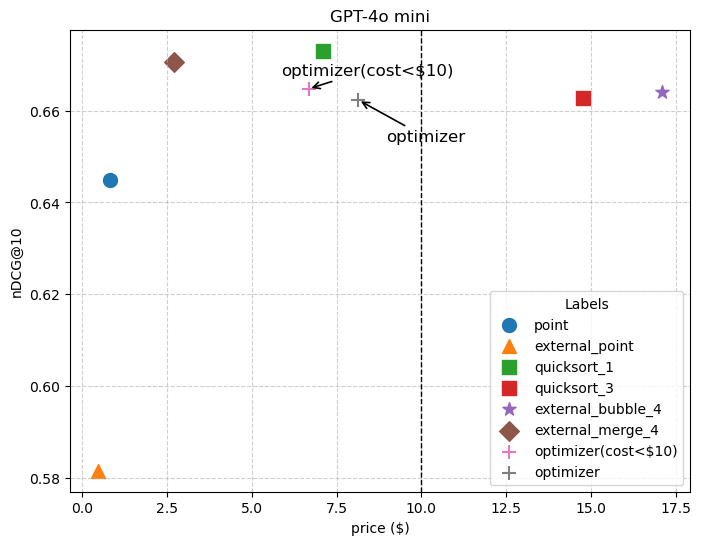

In [21]:
# gpt-4o-mini, pointwise Mean nDCG@10: 0.6448519968848119
# tokens: 2029606, price: 0.807508

# gpt-4o-mini, extrernal pointwise Mean nDCG@10: 0.5815175397221886
# tokens: 1487222, price: 0.471419
    
# gpt-4o-mini, quick_sort Mean nDCG@10: 0.673088012156282
# tokens: 19380112, price: 7.093272

# gpt-4o-mini, quick_sort with vote=3 Mean nDCG@10: 0.6628282551098393
# tokens: 43388495, price: 14.76262
    
# gpt-4o-mini, external_bubble_sort Mean nDCG@10: 0.6641741784435999
# tokens: 50691442, price: 17.103403
    
# gpt-4o-mini, external_merge_sort Mean nDCG@10: 0.6706319549422796
# tokens: 7943468, price: 2.690268
    
    

kendalltau = [0.6448519968848119, 0.5815175397221886,
              0.673088012156282, 0.6628282551098393,
              0.6641741784435999, 0.6706319549422796
             ]
tokens = [2029606, 1487222,
          19380112, 43388495,
          50691442, 7943468
         ]

prices = [0.807508, 0.471419,
          7.093272, 14.76262,
          17.103403, 2.690268
         ]

tokens = [t/(54.0) for t in tokens]
prices = [p for p in prices]


dot_labels = ["point", "external_point",
              "quicksort_1", "quicksort_3",
              "external_bubble_4", "external_merge_4"
             ]
markers = ['o', '^',
           's', 's',
           '*', 'D'
          ] 

# Create scatter plot
plt.figure(figsize=(8, 6))

for x, y, label, m in zip(prices, kendalltau, dot_labels, markers):
    plt.scatter(x, y, s=100, marker=m, label=label)
    
    
# given budget 10
# gpt-4o-mini, optimizer output nDCG@10: 0.6647875148350357
# tokens: 18780325, price: 6.674178

# given budget 200
# gpt-4o-mini, optimizer output nDCG@10: 0.6623403365614713
# tokens: 23386343, price: 8.141381
        
        
        
plt.scatter(6.674178, 0.6647875148350357, s=100, marker='+', label='optimizer(cost<$10)')

plt.annotate(
    'optimizer(cost<$10)',
    xy=(6.674178, 0.6647875148350357),
    xytext=(-20, 10),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)
plt.axvline(x=10, color='black', linestyle='--', linewidth=1)

plt.scatter(8.141381,  0.6623403365614713, s=100, marker='+', label='optimizer')
plt.annotate(
    'optimizer',
    xy=(8.141381,  0.6623403365614713),
    xytext=(20, -30),                # offset in *pixels*
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', lw=1.2),
    fontsize=12,
)


plt.legend(title="Labels")


# Axis labels and title
plt.xlabel("price ($)")
plt.ylabel("nDCG@10")
plt.title("GPT-4o mini")

# Show grid and plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
            
